In [7]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
load_dotenv("../.env")
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
DATASET_PATH=os.path.join("/data/IcaRAus/generated_datasets")
# MODEL_TRAINING_DATASET_PATH=os.getenv("MODEL_TRAINING_DATASET_PATH")
MODEL_TRAINING_DATASET_PATH="/data/IcaRAus/generated_datasets"
GENERATED_DATASETS_PATH=os.getenv("GENERATED_DATASETS_PATH")
GENERATED_DATASETS_PATH="/data/IcaRAus/generated_datasets"


sys.path.append("../")
from cpsl_datasets._base_training_ds import _BaseTrainingDS

from mmwave_model_integrator.input_encoders._input_encoder import _InputEncoder
from mmwave_model_integrator.ground_truth_encoders._gt_encoder import _GTEncoder
from mmwave_model_integrator.plotting.plotter_grids import PlotterGrids


In [8]:
#initialize the dataset
config_label = "IcaRAus_ugv_unet_50fh_wilk_cpsl_north_1st_no_occluded_rt_gt_olp_pts_gt_filter"

dataset_path = os.path.join(DATASET_PATH,"{}_train".format(config_label))
dataset = _BaseTrainingDS(
    dataset_path=dataset_path,
    input_folder="grids",
    label_folder="gt_grids"
)
print(dataset_path)

found 5932 input samples
found 5932 label samples
/data/IcaRAus/generated_datasets/IcaRAus_ugv_unet_50fh_wilk_cpsl_north_1st_no_occluded_rt_gt_olp_pts_gt_filter_train


In [9]:
#initialize the encoder and decoder
input_encoder = _InputEncoder()
ground_truth_encoder = _GTEncoder()
plotter = PlotterGrids(
    max_detection_range=8.0,
    grid_resolution_m=0.1
)

(161, 161)
1


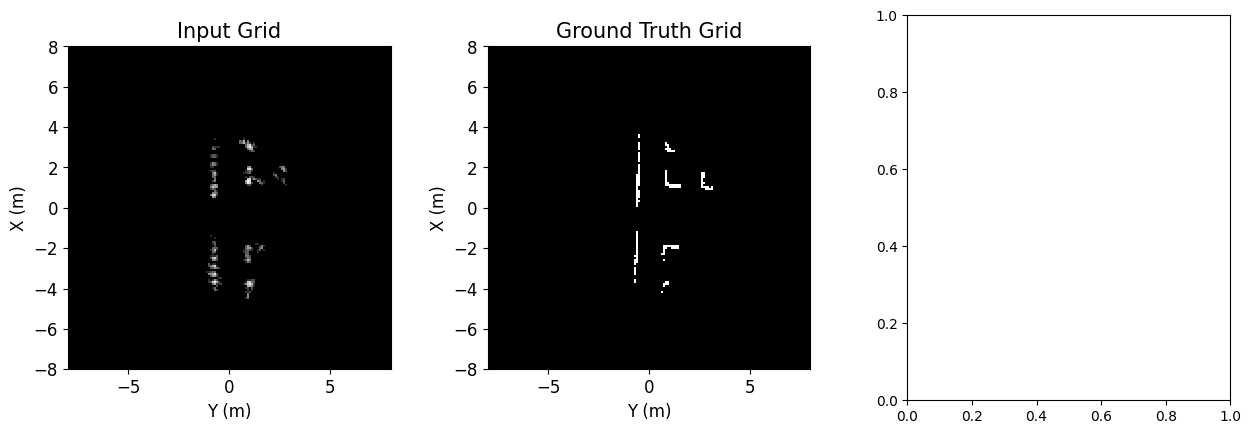

In [10]:
#plot a sample from the training dataset
idx=150
nodes = dataset.get_input_data(idx=idx)
labels = dataset.get_label_data(idx=idx)

print(nodes.shape)
print(labels.max())

plotter.plot_compilation(
    input_data=nodes,
    gt_data=labels,
    input_encoder=input_encoder,
    ground_truth_encoder=ground_truth_encoder,
    show=True
)

In [11]:
from mmwave_model_integrator.config import Config
import mmwave_model_integrator.torch_training.trainers as trainers

# config_path = "../configs/RaGNNarok/RaGNNarok_uav.py"
config_path = "../configs/IcaRAus_unet/IcaRAus_unet_base.py"
config = Config(config_path)

config.print_config()

trainer_config = config.trainer
trainer_class = getattr(trainers,trainer_config.pop('type'))
trainer = trainer_class(**trainer_config)

model=dict(
    type=RadCloudUnet,
    encoder_input_channels=1,
    encoder_out_channels=(64, 128),
    decoder_input_channels=(256, 128),
    decoder_out_channels=64,
    output_channels=1,
    retain_dimmension=False,
    input_dimmensions=(160, 160),
),
generated_dataset=dict(
    input_encoding_folder=grids,
    ground_truth_encoding_folder=gt_grids,
    generated_dataset_path=/data/IcaRAus/generated_datasets/IcaRAus_ugv_unet_50fh_wilk_cpsl_north_1st_no_occluded_rt_gt_olp_pts_gt_filter_train,
),
trainer=dict(
    type=_BaseTorchTrainer,
    model=dict(
        type=RadCloudUnet,
        encoder_input_channels=1,
        encoder_out_channels=(64, 128),
        decoder_input_channels=(256, 128),
        decoder_out_channels=64,
        output_channels=1,
        retain_dimmension=False,
        input_dimmensions=(160, 160),
    ),
    optimizer=dict(
        type=Adam,
        lr=0.001,
    ),
    dataset=dict(
        type=_BaseTorchDataset,
        input_transforms=[{'type': 'ToTe

In [12]:
trainer.train_model()

ModelTrainer.train: training the network...


Epoch:   4%|▍         | 1/25 [01:59<47:51, 119.65s/it]

EPOCH: 1/25
	 Train loss: 0.2687777578830719, Val loss:0.1472836583852768


Epoch:   8%|▊         | 2/25 [03:59<45:54, 119.77s/it]

EPOCH: 2/25
	 Train loss: 0.11932921409606934, Val loss:0.12932005524635315


...

EPOCH: 23/25
	 Train loss: 0.07635215669870377, Val loss:0.09554223716259003


Epoch:  96%|█████████▌| 24/25 [47:54<01:59, 119.70s/it]

EPOCH: 24/25
	 Train loss: 0.07606643438339233, Val loss:0.08923755586147308


EPOCH: 25/25
	 Train loss: 0.07576952874660492, Val loss:0.09991186857223511
ModelTrainer.train: total training time 2994.23


tensor(0.0999, device='cuda:0')